In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
import logging
from mapelite.logging_config import setup_logging
from mapelite.config import LOG_DIR, LOG_CONSOLE_LEVEL, LOG_FILE_LEVEL

log_file = setup_logging(
    log_dir=LOG_DIR,
    console_level=LOG_CONSOLE_LEVEL,   # INFO  → shown on console
    file_level=LOG_FILE_LEVEL,         # DEBUG → written to log file
    log_filename="cvt_mapelite"
)
print(f"Log file: {log_file}")


12:38:02 [INFO] Logging initialised | console_level=INFO file_level=DEBUG log_file=logs\cvt_mapelite_20260326_133802.log


Log file: logs\cvt_mapelite_20260326_133802.log


In [3]:
import numpy as np
import random
import os

import ribs
from ribs.archives import CVTArchive
from ribs.schedulers import Scheduler
from sklearn.cluster import KMeans

from mapelite.emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

In [4]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    CVT_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS,
    EMBEDDING_MODEL_PATH,
    PRECOMPILED_EMBEDDINGS_PATH
)


# --- CVT MAP-Elites specific config ---
checkpoint_dir = os.path.join(CVT_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(CVT_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(CVT_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(CVT_DIR, STATS_FILENAME)
buffer_path = os.path.join(CVT_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
SEED = 67
ELITES_OUTPUT = os.path.join(CVT_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "CVT MAP-Elites (CVTArchive + VAE latent descriptors)"

# --- CVT Archive parameters ---
CVT_CELLS = 300        # number of Voronoi regions (centroids) in the archive
CVT_MEASURES = [(-5, 5)] * EMBEDDING_DIM  # bounds per measure dimension (VAE latent space)

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [5]:
# --- Initialize directories ---
os.makedirs(CVT_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE, model_path=EMBEDDING_MODEL_PATH)

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_3.pth...
Model loaded with latent_dim=32


In [ ]:
import umap
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"]
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=SEED)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")




<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\milob\AppData\Local\Temp\ipykernel_15776\1506961373.py:12: SyntaxWarning: invalid escape sequence '\e'
  umap_model_path = os.path.join("mapelite\embeddings\models", "model_metrics_VAE_latent32_umap.joblib")
d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Loaded precomputed embeddings with shape: (19154, 32)
Saved UMAP model to: mapelite\embeddings\models\model_metrics_VAE_latent32_umap.joblib
UMAP embeddings x,y borders:
x: min=1.4027024507522583, max=13.095444679260254
y: min=-1.5386829376220703, max=5.061985492706299


In [7]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise compute CVT centroids and build archive from scratch
# --------------------------------------------------------------
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)

if state["scheduler"] is not None:
    runner = QDRunner.load_state(
        state, client, evaluator_future, checkpoint_dir, heatmap_dir, gridplot_dir, buffer_path, seed=SEED
    )
else:
    print("Computing CVT centroids...")
    embeddings_data = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"]
    print(f"Loaded {embeddings_data.shape[0]} embeddings ({embeddings_data.shape[1]}D) from {PRECOMPILED_EMBEDDINGS_PATH}")

    km = KMeans(n_clusters=CVT_CELLS, random_state=SEED, n_init=10)
    km.fit(embeddings_data)
    custom_centroids = km.cluster_centers_
    print(f"Computed {custom_centroids.shape[0]} centroids via k-means")

    initial_wss_mean = km.inertia_ / len(embeddings_data)
    print(f"Mean WSS per training track: {initial_wss_mean:.4f}")

    archive = CVTArchive(
        solution_dim=SOLUTION_DIM,
        ranges=CVT_MEASURES,
        cells=CVT_CELLS,
        seed=SEED,
        custom_centroids=custom_centroids,
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))],
        seed=SEED,
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")
    runner = QDRunner(
        scheduler=scheduler, 
        archive=archive,
        client=client,
        evaluator_future=evaluator_future,
        checkpoint_dir=checkpoint_dir,
        heatmap_dir=heatmap_dir,
        gridplot_dir=gridplot_dir,
        buffer_path=buffer_path, 
        seed=SEED,
        centroids=archive.centroids,
        initial_WSS=initial_wss_mean,
    )

12:38:58 [INFO] No checkpoint found — starting fresh


Computing CVT centroids...
Loaded 19154 embeddings (32D) from mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_3.npz
Computed 300 centroids via k-means
Mean WSS per training track: 2.2580


12:39:05 [INFO] Buffer empty — starting fresh | path=data/cvt/buffer.json


Archive, emitter, and scheduler created.


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

12:39:12 [INFO] Emitter.ask called | iteration=0
12:39:49 [INFO] Solution evaluated | score=13.50 sol_id=0.07479375687311074
12:39:49 [INFO] Solution evaluated | score=9.00 sol_id=0.4083858055777375
12:39:49 [INFO] Solution evaluated | score=27.25 sol_id=0.4152931888911857
12:39:49 [INFO] Solution evaluated | score=10.00 sol_id=0.4294663778527732
12:39:49 [INFO] Solution evaluated | score=12.75 sol_id=0.27802585750411557
12:39:49 [INFO] Solution evaluated | score=7.00 sol_id=0.6437989699821243
12:39:49 [INFO] Solution evaluated | score=10.75 sol_id=0.17677089786513922
12:39:49 [INFO] Solution evaluated | score=6.50 sol_id=0.15800944298104402
12:39:49 [INFO] Solution evaluated | score=24.25 sol_id=0.12301756950269216
12:39:49 [INFO] Solution evaluated | score=10.75 sol_id=0.4912005313353208
12:39:50 [INFO] Iteration complete | batch_best=27.25 global_best=27.25 global_best_id=0.4152931888911857 iteration=0 new_elites=10 substituted=0
12:39:50 [INFO] Archive stats | best=27.25 mean=13.44

KeyboardInterrupt: 

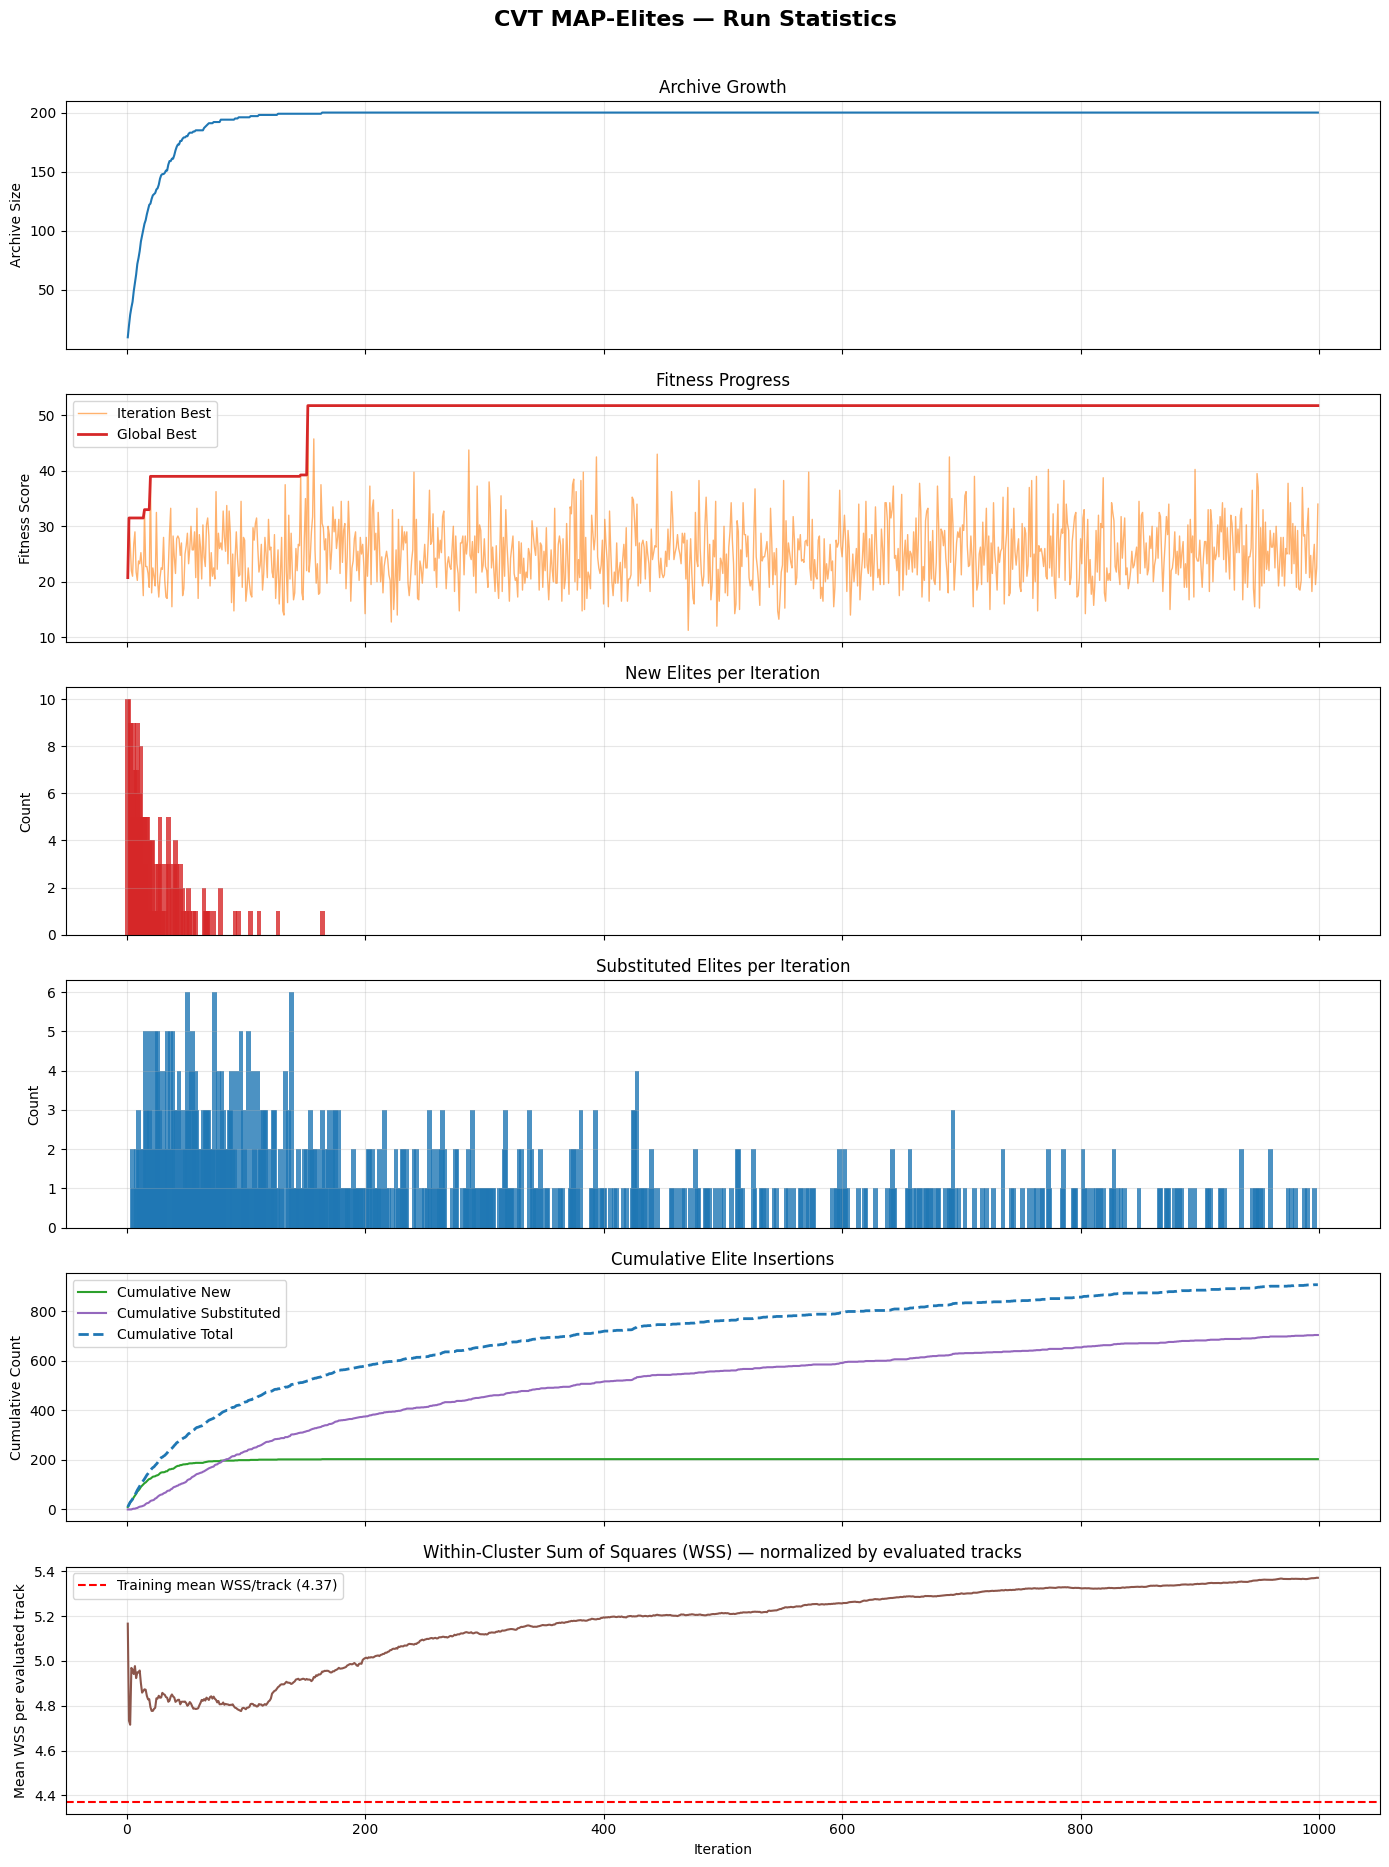


  CVT MAP-Elites Summary
  Total iterations:        999
  Final archive size:      200
  Global best fitness:     51.7500
  Total new elites:        203
  Total substituted:       704
  Avg new elites/iter:     0.20
  Avg substituted/iter:    0.70


In [ ]:
runner.visualizer.plot_stats(title="CVT MAP-Elites")

In [ ]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
)

Saved 200 elites to data/cvt/elites.json
  Best fitness:  51.7500 (ID=151.46183890031904)
  Worst fitness: 9.2500
  File size:     2189.7 KB
